<a href="https://colab.research.google.com/github/Cristiand056/practicas_IA/blob/main/breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wasiqaliyasir/breast-cancer-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/breast-cancer-dataset


In [3]:
import os

data_link = os.path.join(path, 'Breast_cancer_dataset.csv')

In [4]:
import pandas as pd
import numpy as np

data = pd.read_csv(data_link)
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
data = data.drop(columns=['Unnamed: 32'], axis=1)

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])

In [8]:
data.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,1,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,1,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,1,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,1,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,1,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


# prueba propuesta por el autor del dataset

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X = data.drop(columns=['id', 'diagnosis'], axis=1)
y = data['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

Accuracy: 0.9649122807017544
R2: 0.8476445038422986
Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        73
           1       0.91      1.00      0.95        41

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

Matriz de confusión:
[[69  4]
 [ 0 41]]


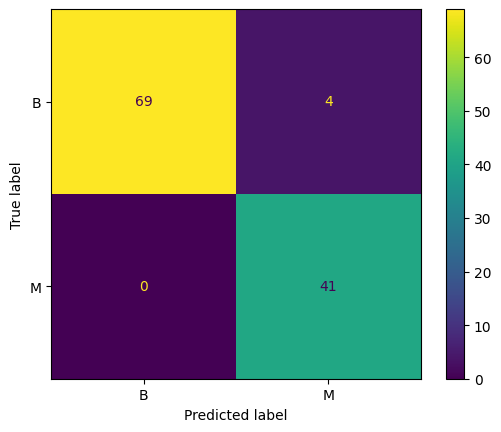

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, r2_score, accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
matriz = confusion_matrix(y_test, y_pred)
visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["B","M"])
visualizacion.plot()

print("Accuracy:", accuracy)
print("R2:", r2)
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

print("Matriz de confusión:")
print(matriz)

#Otros modelos

Accuracy: 0.6228070175438597
R2: -0.5390894819466243
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.62      0.88      0.73        65
           1       0.64      0.29      0.39        49

    accuracy                           0.62       114
   macro avg       0.63      0.58      0.56       114
weighted avg       0.63      0.62      0.58       114

Matriz de confusión:
[[57  8]
 [35 14]]


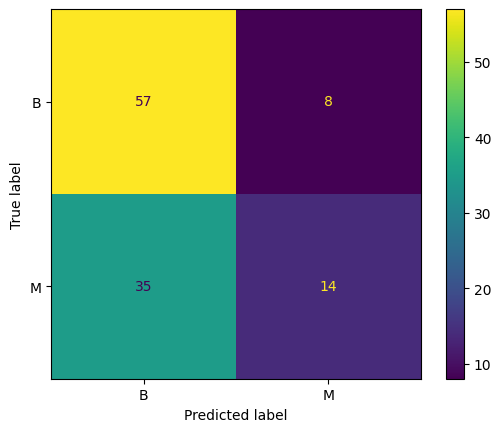

In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler

minMaxSc = MinMaxScaler()
X_sca = minMaxSc.fit_transform(X)

X_train_sca, X_test_sca, y_train_sca, y_test_sca = train_test_split(X_sca, y, test_size=0.2)

knn = KNeighborsClassifier(n_neighbors=3)
knn = knn.fit(X_train_sca, y_train_sca)


y_pred = model.predict(X_test_sca)

accuracy = accuracy_score(y_test_sca, y_pred)
r2 = r2_score(y_test_sca, y_pred)
matriz = confusion_matrix(y_test_sca, y_pred)
visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["B","M"])
visualizacion.plot()

print("Accuracy:", accuracy)
print("R2:", r2)
print("Reporte de clasificación:")
print(classification_report(y_test_sca, y_pred))

print("Matriz de confusión:")
print(matriz)

In [12]:
from tensorflow import keras
from keras import layers

In [13]:
model_keras = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_keras.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'recall'])

model_keras.summary()

history = model_keras.fit(X_train_sca, y_train_sca, epochs=40, batch_size=32, validation_split=0.2, verbose=1)

test_loss, test_accuracy, test_recall = model_keras.evaluate(X_test_sca, y_test_sca)
print(f"\nPrecisión en el conjunto de prueba: {test_accuracy:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4151 - loss: 0.7063 - recall: 0.6580 - val_accuracy: 0.6154 - val_loss: 0.6760 - val_recall: 0.8966
Epoch 2/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6137 - loss: 0.6682 - recall: 0.7539 - val_accuracy: 0.7582 - val_loss: 0.6508 - val_recall: 0.7931
Epoch 3/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6649 - loss: 0.6531 - recall: 0.6829 - val_accuracy: 0.7802 - val_loss: 0.6273 - val_recall: 0.6207
Epoch 4/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7324 - loss: 0.6352 - recall: 0.5842 - val_accuracy: 0.8132 - val_loss: 0.6075 - val_recall: 0.4828
Epoch 5/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7491 - loss: 0.6240 - recall: 0.5079 - val_accuracy: 0.8352 - val_loss: 0.5897 - val_recall: 0.5862
Epoch 6/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7719 - loss: 0.6045 - recall: 0.6177 - val_accuracy: 0.8901 - val_loss: 0.5707 - val_recall: 0.7586
Epoch 7/40
12

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Accuracy: 0.956140350877193
R2: 0.8210361003875732
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        65
           1       0.92      0.98      0.95        49

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

Matriz de confusión:
[[61  4]
 [ 1 48]]


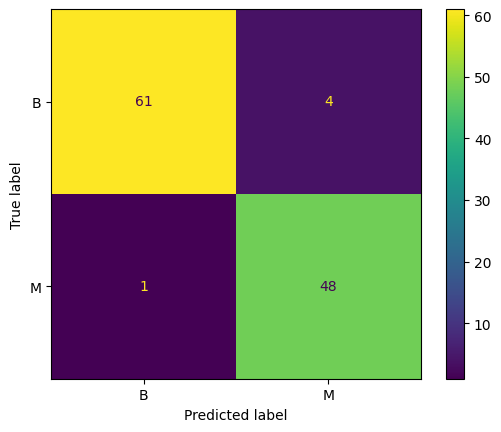

In [14]:
y_pred = model_keras.predict(X_test_sca)

accuracy = accuracy_score(y_test_sca, y_pred.round())
r2 = r2_score(y_test_sca, y_pred.round())
matriz = confusion_matrix(y_test_sca, y_pred.round())
visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["B","M"])
visualizacion.plot()

print("Accuracy:", accuracy)
print("R2:", r2)
print("Reporte de clasificación:")
print(classification_report(y_test_sca, y_pred.round()))

print("Matriz de confusión:")
print(matriz)